In [86]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

ignorewarnings = True

# Collecting Data Pertumbuhan Tanaman

In [ ]:
df_jumlah_daun = pd.read_excel('dataTumbuhan/jumlahDaun.xlsx')
df_jumlah_daun.head()

,Tanaman Selada,0,3,6,9,12,15,18,21,24,27,30
0,1,4,5,6,6,7,9,9,11,14,15,17
1,2,4,6,7,7,9,10,11,11,12,12,13
2,3,4,6,7,7,7,7,10,10,10,15,17
3,4,5,6,6,7,8,9,10,14,16,16,16
4,5,3,5,5,6,6,8,9,10,11,15,19


In [13]:
df_lebar_daun = pd.read_excel('dataTumbuhan/lebarDaun.xlsx')
df_lebar_daun.head()

,Tanaman Selada,0,3,6,9,12,15,18,21,24,27,30
0,1,1.30,1.5,2.1,3.1,4,5.6,6.9,9.4,11.8,11.3,10.7
1,2,1.08,1.8,2.3,2.8,4,5.7,7.1,9.2,11.2,10.1,9.0
2,3,1.24,1.4,2.5,3.3,3.6,4.5,8.0,9.5,11.0,10.6,10.2
3,4,1.20,2.0,2.8,3.2,4.6,6.0,8.3,10.3,12.3,10.8,9.2
4,5,1.30,1.5,1.8,2.9,3.6,4.5,5.7,8.0,10.3,12.0,13.7


In [14]:
df_panjang_daun = pd.read_excel('dataTumbuhan/panjangDaun.xlsx')
df_panjang_daun.head()

,Tanaman Selada,0,3,6,9,12,15,18,21,24,27,30
0,1,1.50,2.5,3.4,5.8,7.2,8.3,11.6,12.8,14.0,13.2,12.3
1,2,2.08,2.8,3.2,4.6,6.0,9.3,11.0,12.5,14.0,12.7,11.3
2,3,1.50,2.5,3.1,5.0,6.2,8.1,9.2,10.8,12.3,12.7,13.0
3,4,2.20,3.0,3.0,6.0,7.3,10.0,12.0,13.0,14.0,13.3,12.5
4,5,1.38,2.3,2.4,4.0,5.5,7.0,9.0,10.9,12.7,13.6,14.5


In [15]:
df_tinggi_tanaman = pd.read_excel('dataTumbuhan/tinggiTanaman.xlsx')
df_tinggi_tanaman.head()

,Tanaman Selada,0,3,6,9,12,15,18,21,24,27,30
0,1,2.04,4.0,5.5,7.6,8.8,10.5,12.9,14.1,15.3,14.6,13.9
1,2,2.46,4.1,5.6,5.8,8.2,10.3,12.5,14.1,15.8,14.3,12.8
2,3,2.16,3.6,5.5,7.4,8.3,9.1,10.9,12.2,13.5,14.0,14.5
3,4,2.52,4.2,5.9,7.5,9.7,11.5,13.0,14.5,16.0,15.1,14.2
4,5,2.28,3.8,4.5,5.5,7.1,8.8,9.8,11.7,13.5,15.1,16.7


### Ubah format data tanaman menjadi perhari untuk baris

In [22]:
df_jumlah_daun_long = df_jumlah_daun.melt(
    id_vars=["Tanaman Selada"],
    var_name="hari_ke",
    value_name="jumlah_daun"
)
df_jumlah_daun_long.head()

,Tanaman Selada,hari_ke,jumlah_daun
0,1,0,4
1,2,0,4
2,3,0,4
3,4,0,5
4,5,0,3


In [23]:
df_lebar_daun_long = df_lebar_daun.melt(
    id_vars=["Tanaman Selada"],
    var_name="hari_ke",
    value_name="lebar_daun"
)
df_lebar_daun_long.head()

,Tanaman Selada,hari_ke,lebar_daun
0,1,0,1.3
1,2,0,1.08
2,3,0,1.24
3,4,0,1.2
4,5,0,1.3


In [24]:
df_panjang_daun_long = df_panjang_daun.melt(
    id_vars=["Tanaman Selada"],
    var_name="hari_ke",
    value_name="panjang_daun"
)
df_panjang_daun_long.head()

,Tanaman Selada,hari_ke,panjang_daun
0,1,0,1.50
1,2,0,2.08
2,3,0,1.50
3,4,0,2.20
4,5,0,1.38


In [25]:
df_tinggi_tanaman_long = df_tinggi_tanaman.melt(
    id_vars=["Tanaman Selada"],
    var_name="hari_ke",
    value_name="tinggi_tanaman"
)
df_tinggi_tanaman_long.head()

,Tanaman Selada,hari_ke,tinggi_tanaman
0,1,0,2.04
1,2,0,2.46
2,3,0,2.16
3,4,0,2.52
4,5,0,2.28


In [28]:
for df in [df_jumlah_daun_long, df_tinggi_tanaman_long, df_panjang_daun_long, df_lebar_daun_long]:
    df["hari_ke"] = df["hari_ke"].astype(int)
    df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Tanaman Selada  605 non-null    int64
 1   hari_ke         605 non-null    int32
 2   jumlah_daun     605 non-null    int64
dtypes: int32(1), int64(2)
memory usage: 11.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tanaman Selada  605 non-null    int64  
 1   hari_ke         605 non-null    int32  
 2   tinggi_tanaman  605 non-null    float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 11.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Tanaman Selada  605 non-null    int64  
 1 

In [29]:
df_gabungan = df_jumlah_daun_long.merge(df_tinggi_tanaman_long, on=["Tanaman Selada", "hari_ke"], how="outer")
df_gabungan = df_gabungan.merge(df_panjang_daun_long, on=["Tanaman Selada", "hari_ke"], how="outer")
df_gabungan = df_gabungan.merge(df_lebar_daun_long, on=["Tanaman Selada", "hari_ke"], how="outer")

In [30]:
df_gabungan.head()

,Tanaman Selada,hari_ke,jumlah_daun,tinggi_tanaman,panjang_daun,lebar_daun
0,1,0,4,2.04,1.50,1.3
1,2,0,4,2.46,2.08,1.08
2,3,0,4,2.16,1.50,1.24
3,4,0,5,2.52,2.20,1.2
4,5,0,3,2.28,1.38,1.3


In [31]:
df_gabungan.to_excel("gabungan_data.xlsx", index=False)

# Collecting Data Sensor

In [33]:
base_path = "Excel penelitian"
data_list = []

In [35]:
for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    if os.path.isdir(folder_path):
        tanggal = folder

        try:
            ph = pd.read_excel(os.path.join(folder_path, "pH.xlsx"))
            ppm = pd.read_excel(os.path.join(folder_path, "PPM.xlsx"))
            suhu_air = pd.read_excel(os.path.join(folder_path, "Suhu air.xlsx"))
            suhu_dht = pd.read_excel(os.path.join(folder_path, "Suhu dht.xlsx"))
            hum_dht = pd.read_excel(os.path.join(folder_path, "Humadity dht.xlsx"))

            avg_ph = ph.mean(numeric_only=True).mean()
            avg_ppm = ppm.mean(numeric_only=True).mean()
            avg_suhu_air = suhu_air.mean(numeric_only=True).mean()
            avg_suhu_dht = suhu_dht.mean(numeric_only=True).mean()
            avg_hum_dht = hum_dht.mean(numeric_only=True).mean()

            data_list.append({
                "tanggal": tanggal,
                "ph": avg_ph,
                "ppm": avg_ppm,
                "suhu_air": avg_suhu_air,
                "suhu_dht": avg_suhu_dht,
                "humidity_dht": avg_hum_dht
            })
        except Exception as e:
            print(f"Gagal baca folder {folder}: {e}")

df_sensor = pd.DataFrame(data_list)

In [36]:
df_sensor["tanggal"] = pd.to_datetime(df_sensor["tanggal"], format="%d-%m-%Y")

In [37]:
df_sensor = df_sensor.sort_values("tanggal")

In [38]:
df_sensor.head()

,tanggal,ph,ppm,suhu_air,suhu_dht,humidity_dht
34,2025-07-29,6.066393,888.677043,28.264710,31.636839,70.785572
35,2025-07-30,6.074200,899.197696,29.782634,28.664605,81.157431
15,2025-07-30,6.074200,899.197696,29.782634,28.664605,81.157431
36,2025-07-31,6.078210,891.725696,29.292634,28.225913,83.321099
16,2025-07-31,6.078210,891.725696,29.292634,28.225913,83.321099


In [39]:
df_sensor.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 37 entries, 34 to 14
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tanggal       37 non-null     datetime64[ns]
 1   ph            36 non-null     float64       
 2   ppm           37 non-null     float64       
 3   suhu_air      37 non-null     float64       
 4   suhu_dht      37 non-null     float64       
 5   humidity_dht  37 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 KB


In [40]:
df_sensor["tanggal"].sort_values().unique()

array(['2025-07-29T00:00:00.000000000', '2025-07-30T00:00:00.000000000',
       '2025-07-31T00:00:00.000000000', '2025-08-01T00:00:00.000000000',
       '2025-08-02T00:00:00.000000000', '2025-08-03T00:00:00.000000000',
       '2025-08-05T00:00:00.000000000', '2025-08-06T00:00:00.000000000',
       '2025-08-07T00:00:00.000000000', '2025-08-08T00:00:00.000000000',
       '2025-08-09T00:00:00.000000000', '2025-08-10T00:00:00.000000000',
       '2025-08-11T00:00:00.000000000', '2025-08-12T00:00:00.000000000',
       '2025-08-13T00:00:00.000000000', '2025-08-16T00:00:00.000000000',
       '2025-08-19T00:00:00.000000000', '2025-08-22T00:00:00.000000000',
       '2025-08-25T00:00:00.000000000', '2025-08-28T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [41]:
print("Tanggal paling awal:", df_sensor["tanggal"].min())
print("Tanggal paling akhir:", df_sensor["tanggal"].max())

Tanggal paling awal: 2025-07-29 00:00:00
Tanggal paling akhir: 2025-08-28 00:00:00


In [42]:
duplicates = df_sensor[df_sensor.duplicated(subset="tanggal", keep=False)]
print(duplicates)

      tanggal       ph          ppm   suhu_air   suhu_dht  humidity_dht
35 2025-07-30  6.07420   899.197696  29.782634  28.664605     81.157431
15 2025-07-30  6.07420   899.197696  29.782634  28.664605     81.157431
36 2025-07-31  6.07821   891.725696  29.292634  28.225913     83.321099
16 2025-07-31  6.07821   891.725696  29.292634  28.225913     83.321099
0  2025-08-02  6.06830   909.949696  27.625678  29.069981     78.720740
18 2025-08-02  6.06830   909.949696  27.625678  29.069981     78.720740
1  2025-08-03  6.08021   888.245696  29.482634  27.932372     81.626623
19 2025-08-03  6.08021   888.245696  29.482634  27.932372     81.626623
20 2025-08-05  6.07721  1000.384101  29.481634  28.343120     80.524614
2  2025-08-05  6.07721  1000.384101  29.481634  28.343120     80.524614
3  2025-08-06  6.07321  1004.280029  29.881634  30.297492     77.110177
21 2025-08-06  6.07321  1004.280029  29.881634  30.297492     77.110177
4  2025-08-07  6.06920  1012.481329  28.235678  27.935678     84

In [43]:
df_sensor = df_sensor.sort_values("tanggal")
df_sensor["diff_days"] = df_sensor["tanggal"].diff().dt.days
print(df_sensor[["tanggal", "diff_days"]])

      tanggal  diff_days
34 2025-07-29        NaN
35 2025-07-30        1.0
15 2025-07-30        0.0
36 2025-07-31        1.0
16 2025-07-31        0.0
17 2025-08-01        1.0
0  2025-08-02        1.0
18 2025-08-02        0.0
19 2025-08-03        1.0
1  2025-08-03        0.0
20 2025-08-05        2.0
2  2025-08-05        0.0
3  2025-08-06        1.0
21 2025-08-06        0.0
4  2025-08-07        1.0
22 2025-08-07        0.0
23 2025-08-08        1.0
5  2025-08-08        0.0
6  2025-08-09        1.0
24 2025-08-09        0.0
25 2025-08-10        1.0
7  2025-08-10        0.0
26 2025-08-11        1.0
8  2025-08-11        0.0
27 2025-08-12        1.0
9  2025-08-12        0.0
10 2025-08-13        1.0
28 2025-08-13        0.0
29 2025-08-16        3.0
11 2025-08-19        3.0
30 2025-08-19        0.0
12 2025-08-22        3.0
31 2025-08-22        0.0
13 2025-08-25        3.0
32 2025-08-25        0.0
33 2025-08-28        3.0
14 2025-08-28        0.0


In [44]:
print(df_sensor.info())
print(df_sensor.isna().sum())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 37 entries, 34 to 14
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tanggal       37 non-null     datetime64[ns]
 1   ph            36 non-null     float64       
 2   ppm           37 non-null     float64       
 3   suhu_air      37 non-null     float64       
 4   suhu_dht      37 non-null     float64       
 5   humidity_dht  37 non-null     float64       
 6   diff_days     36 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 2.3 KB
None
tanggal         0
ph              1
ppm             0
suhu_air        0
suhu_dht        0
humidity_dht    0
diff_days       1
dtype: int64


#### Wrangling data

In [45]:
df_sensor_clean = df_sensor.drop_duplicates(subset="tanggal").sort_values("tanggal")

In [46]:
df_sensor_clean["ph"] = df_sensor_clean["ph"].interpolate(method="linear")

In [47]:
tanggal_penuh = pd.date_range(df_sensor_clean["tanggal"].min(), df_sensor_clean["tanggal"].max())

In [48]:
df_sensor_clean = df_sensor_clean.set_index("tanggal").reindex(tanggal_penuh).rename_axis("tanggal").reset_index()

In [50]:
df_sensor_clean[df_sensor_clean.select_dtypes(include=['float64']).columns] = (
    df_sensor_clean.select_dtypes(include=['float64']).interpolate(method='linear')
)

In [55]:
df_sensor_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tanggal       31 non-null     datetime64[ns]
 1   ph            31 non-null     float64       
 2   ppm           31 non-null     float64       
 3   suhu_air      31 non-null     float64       
 4   suhu_dht      31 non-null     float64       
 5   humidity_dht  31 non-null     float64       
 6   diff_days     30 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 1.8 KB


In [56]:
df_sensor_clean['tanggal'] = pd.to_datetime(df_sensor_clean['tanggal'], errors='coerce')

In [57]:
df_sensor_clean['diff_days'] = (df_sensor_clean['tanggal'] - df_sensor_clean['tanggal'].min()).dt.days

In [58]:
df_sensor_clean.isna().sum()

tanggal         0
ph              0
ppm             0
suhu_air        0
suhu_dht        0
humidity_dht    0
diff_days       0
dtype: int64

In [59]:
df_sensor_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tanggal       31 non-null     datetime64[ns]
 1   ph            31 non-null     float64       
 2   ppm           31 non-null     float64       
 3   suhu_air      31 non-null     float64       
 4   suhu_dht      31 non-null     float64       
 5   humidity_dht  31 non-null     float64       
 6   diff_days     31 non-null     int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 1.8 KB


In [60]:
df_sensor_clean.head()

,tanggal,ph,ppm,suhu_air,suhu_dht,humidity_dht,diff_days
0,2025-07-29,6.066393,888.677043,28.264710,31.636839,70.785572,0
1,2025-07-30,6.074200,899.197696,29.782634,28.664605,81.157431,1
2,2025-07-31,6.078210,891.725696,29.292634,28.225913,83.321099,2
3,2025-08-01,6.073255,907.181192,29.152341,30.018621,78.052429,3
4,2025-08-02,6.068300,909.949696,27.625678,29.069981,78.720740,4


In [61]:
df_sensor_clean["diff_days"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
      dtype=int64)

In [62]:
df_sensor_clean['hari_ke'] = range(len(df_sensor_clean))

In [63]:
df_sensor_clean.head()

,tanggal,ph,ppm,suhu_air,suhu_dht,humidity_dht,diff_days,hari_ke
0,2025-07-29,6.066393,888.677043,28.264710,31.636839,70.785572,0,0
1,2025-07-30,6.074200,899.197696,29.782634,28.664605,81.157431,1,1
2,2025-07-31,6.078210,891.725696,29.292634,28.225913,83.321099,2,2
3,2025-08-01,6.073255,907.181192,29.152341,30.018621,78.052429,3,3
4,2025-08-02,6.068300,909.949696,27.625678,29.069981,78.720740,4,4


In [64]:
df_sensor_clean["hari_ke"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30],
      dtype=int64)

In [65]:
df_sensor_clean = df_sensor_clean.drop(columns=['diff_days'])

# Merge dua dataset

In [66]:
df_final = pd.merge(df_gabungan, df_sensor_clean, on='hari_ke', how='left')

In [67]:
df_final.head()

,Tanaman Selada,hari_ke,jumlah_daun,tinggi_tanaman,panjang_daun,lebar_daun,tanggal,ph,ppm,suhu_air,suhu_dht,humidity_dht
0,1,0,4,2.04,1.50,1.3,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572
1,2,0,4,2.46,2.08,1.08,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572
2,3,0,4,2.16,1.50,1.24,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572
3,4,0,5,2.52,2.20,1.2,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572
4,5,0,3,2.28,1.38,1.3,2025-07-29,6.066393,888.677043,28.26471,31.636839,70.785572


In [69]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanaman Selada  605 non-null    int64         
 1   hari_ke         605 non-null    int32         
 2   jumlah_daun     605 non-null    int64         
 3   tinggi_tanaman  605 non-null    float64       
 4   panjang_daun    605 non-null    float64       
 5   lebar_daun      605 non-null    object        
 6   tanggal         605 non-null    datetime64[ns]
 7   ph              605 non-null    float64       
 8   ppm             605 non-null    float64       
 9   suhu_air        605 non-null    float64       
 10  suhu_dht        605 non-null    float64       
 11  humidity_dht    605 non-null    float64       
dtypes: datetime64[ns](1), float64(7), int32(1), int64(2), object(1)
memory usage: 59.1+ KB


In [70]:
df_final['lebar_daun'] = pd.to_numeric(df_final['lebar_daun'], errors='coerce')

In [73]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 605 entries, 0 to 604
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Tanaman Selada  605 non-null    int64         
 1   hari_ke         605 non-null    int32         
 2   jumlah_daun     605 non-null    int64         
 3   tinggi_tanaman  605 non-null    float64       
 4   panjang_daun    605 non-null    float64       
 5   lebar_daun      604 non-null    float64       
 6   tanggal         605 non-null    datetime64[ns]
 7   ph              605 non-null    float64       
 8   ppm             605 non-null    float64       
 9   suhu_air        605 non-null    float64       
 10  suhu_dht        605 non-null    float64       
 11  humidity_dht    605 non-null    float64       
dtypes: datetime64[ns](1), float64(8), int32(1), int64(2)
memory usage: 59.1 KB


In [72]:
df_final.to_excel("data_final.xlsx", index=False)

# Pelatihan Model

In [75]:
print(df_final.describe())

       Tanaman Selada     hari_ke  jumlah_daun  tinggi_tanaman  panjang_daun  \
count      605.000000  605.000000   605.000000      605.000000    605.000000   
mean        28.000000   15.000000     9.193388        9.419702      8.131702   
std         15.887644    9.494683     3.845608        4.291513      4.376225   
min          1.000000    0.000000     3.000000        2.000000      1.260000   
25%         14.000000    6.000000     6.000000        5.500000      3.600000   
50%         28.000000   15.000000     9.000000        9.800000      8.500000   
75%         42.000000   24.000000    12.000000       13.500000     12.300000   
max         55.000000   30.000000    21.000000       17.600000     16.200000   

       lebar_daun          ph          ppm    suhu_air    suhu_dht  \
count  604.000000  605.000000   605.000000  605.000000  605.000000   
mean     5.987285    6.079178  1055.401306   29.089845   29.036266   
std      3.617972    0.008010   118.446057    0.831259    1.197093   

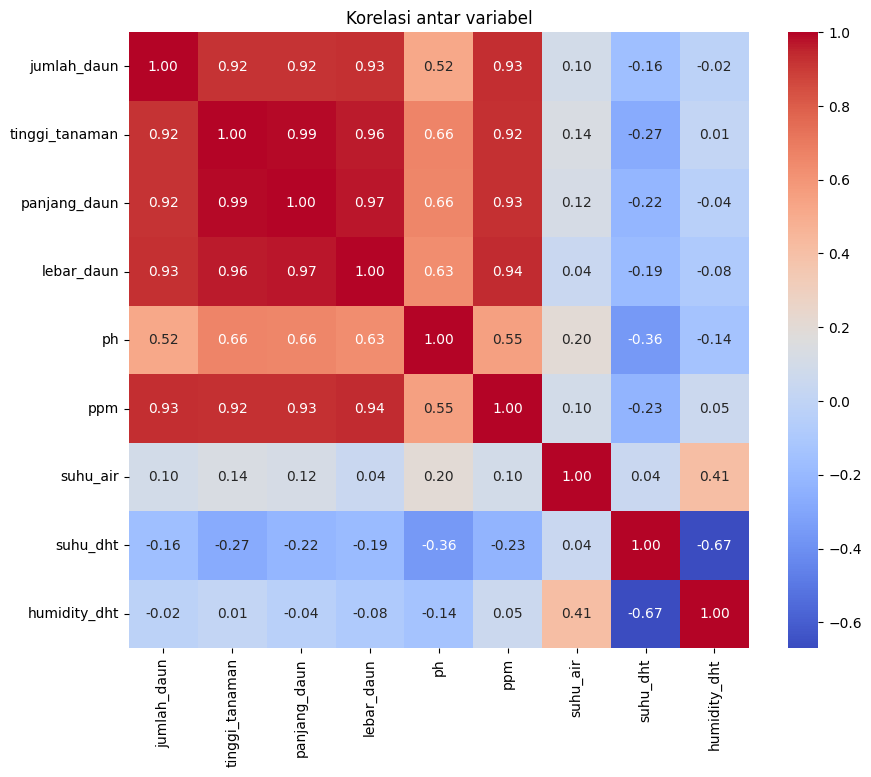

In [88]:
corr = df_final[['jumlah_daun','tinggi_tanaman','panjang_daun','lebar_daun','ph','ppm','suhu_air','suhu_dht','humidity_dht']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Korelasi antar variabel')
plt.show()

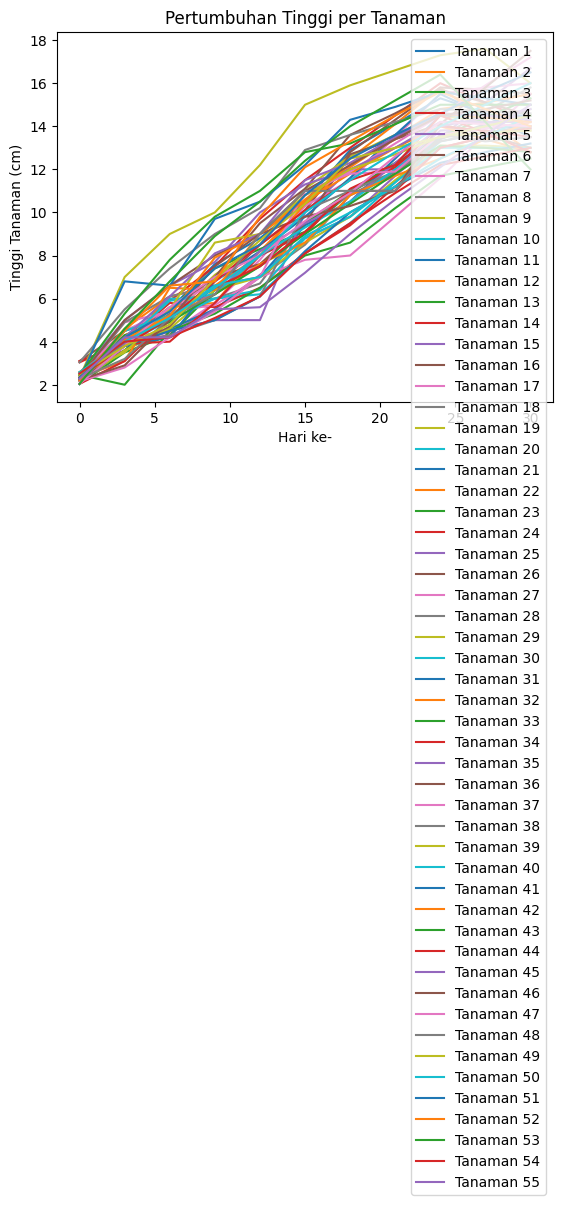

In [90]:
for tanaman in df_final['Tanaman Selada'].unique():
    subset = df_final[df_final['Tanaman Selada'] == tanaman]
    plt.plot(subset['hari_ke'], subset['tinggi_tanaman'], label=f'Tanaman {tanaman}')

plt.xlabel('Hari ke-')
plt.ylabel('Tinggi Tanaman (cm)')
plt.title('Pertumbuhan Tinggi per Tanaman')
plt.legend()
plt.show()

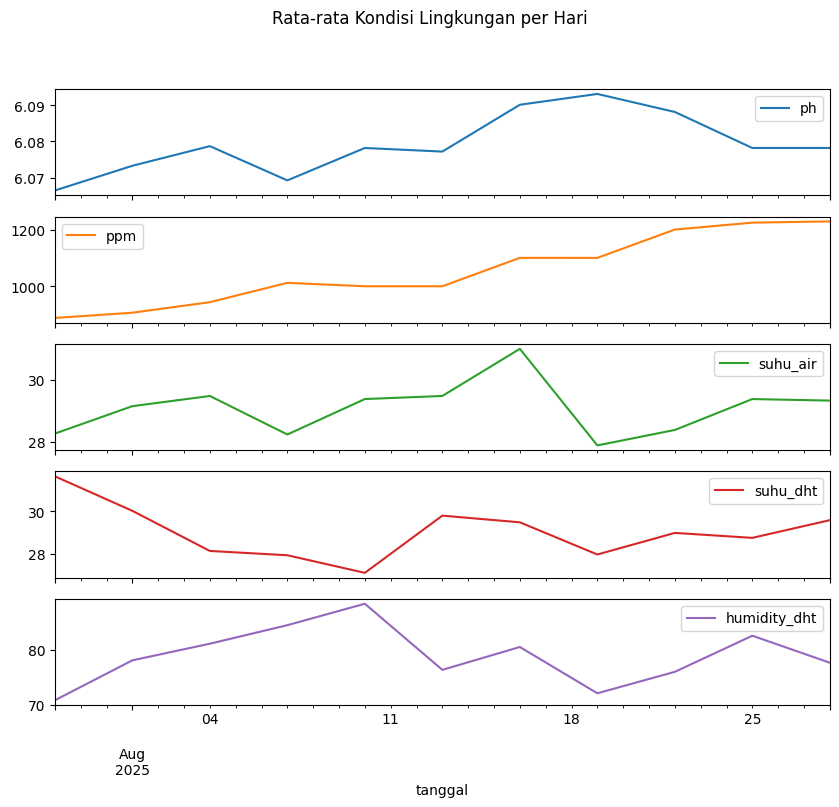

In [92]:
df_final.groupby('tanggal')[['ph','ppm','suhu_air','suhu_dht','humidity_dht']].mean().plot(subplots=True, figsize=(10,8))
plt.suptitle('Rata-rata Kondisi Lingkungan per Hari')
plt.show()

In [94]:
X = df_final[['ph', 'suhu_air', 'suhu_dht', 'humidity_dht', 
        'hari_ke', 'jumlah_daun', 'tinggi_tanaman', 
        'panjang_daun', 'lebar_daun']]

y = df_final['ppm']


In [95]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [96]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [97]:
y_pred = model.predict(X_test)

In [98]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [99]:
print(f"MAE: {mae:.2f}")
print(f"R²: {r2:.3f}")

MAE: 0.01
R²: 1.000


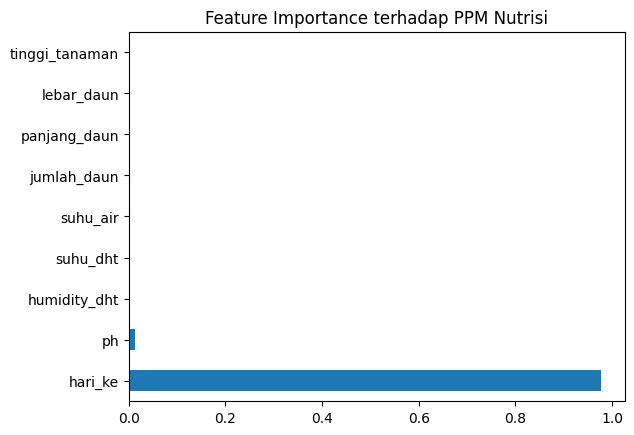

In [100]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
feat_imp.plot(kind='barh')
plt.title("Feature Importance terhadap PPM Nutrisi")
plt.show()